In [15]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import chi2
from sklearn.neighbors import KernelDensity
from sklearn.base import TransformerMixin, BaseEstimator
sns.set(style='whitegrid')

In [2]:
sms = pd.read_csv('SMSSpamCollection', delimiter='	', header=None, names=['label','text'])
sms['label'] = sms['label'].map({'ham': 0, 'spam': 1}).astype('int8')
sms.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Analiza macierzy zliczeń: rozkład długości wiadomości, najczęstsze tokeny i dyspersja cech.

DTM shape: (5572, 8713)


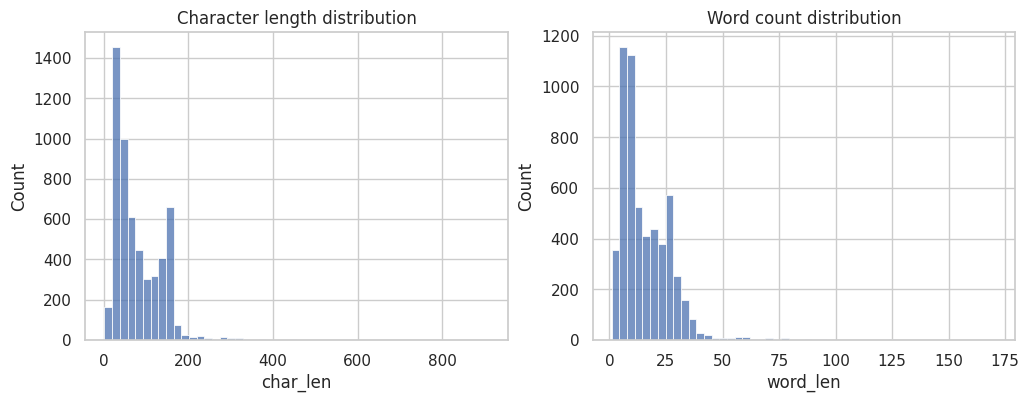

Top 20 terms (by frequency):
['to' 'you' 'the' 'and' 'in' 'is' 'me' 'my' 'it' 'for' 'your' 'of' 'call'
 'that' 'have' 'on' 'now' 'are' 'can' 'so']
Top 20 terms by dispersion (var/mean):
['face' 'mumtaz' 'grl' 'empty' 'missing' 'simple' 'happy' 'footprints'
 'blah' 'bloo' 'dsn' 'crab' 'ubi' 'tick' 'wer' 'bid' 'charity' 'hmv' 'sky'
 'insurance']


In [3]:
vect = CountVectorizer(ngram_range=(1,1), min_df=1)
X_counts = vect.fit_transform(sms['text'])
y = sms['label'].values
print('DTM shape:', X_counts.shape)
# Rozkład długości wiadomości (znaki i tokeny)
sms['char_len'] = sms['text'].str.len()
sms['word_len'] = sms['text'].str.split().str.len()
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(sms['char_len'], bins=50)
plt.title('Character length distribution')
plt.subplot(1,2,2)
sns.histplot(sms['word_len'], bins=50)
plt.title('Word count distribution')
plt.show()
term_sums = np.array(X_counts.sum(axis=0)).ravel()
terms = np.array(vect.get_feature_names_out())
top_idx = np.argsort(term_sums)[-20:][::-1]
print('Top 20 terms (by frequency):')
print(terms[top_idx])
n_docs = X_counts.shape[0]
term_mean = term_sums / n_docs
term_sq_sums = np.array(X_counts.power(2).sum(axis=0)).ravel()
term_var = term_sq_sums / n_docs - term_mean**2
dispersion = term_var / (term_mean + 1e-12)
disp_idx = np.argsort(dispersion)[-20:][::-1]
print('Top 20 terms by dispersion (var/mean):')
print(terms[disp_idx])

- Klasy: ham 4825, spam 747 - znaczna nierównowaga (~13% spam).
- Większość wiadomości jest krótka (kilka słów) - warto rozważyć min_df i ngram_range.
- Tokeny o dużej dyspersji (np. "call", "free") mogą być silnymi cechami separującymi.

Przeszukiwanie parametrów wektoryzatora (ngram_range, min_df, max_df) i parametrów modelu przy metryce ROC AUC.

In [4]:
pipe_mnb = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('clf', MultinomialNB())])
param_grid_mnb = {
    'vect__ngram_range': [(1,1),(1,2)],
    'vect__min_df': [1,2,5],
    'vect__max_df': [0.9,0.95],
    'tfidf__use_idf': [True, False],
    'clf__alpha': [0.1, 1.0]
}
gs_mnb = GridSearchCV(pipe_mnb, param_grid_mnb, scoring='roc_auc', cv=5, n_jobs=-1, verbose=0)
print('Running GridSearch for MultinomialNB (this may take a while)')
gs_mnb.fit(X_train, y_train)
print('Best MNB params:', gs_mnb.best_params_)
print('Best MNB CV ROCAUC:', gs_mnb.best_score_)

Running GridSearch for MultinomialNB (this may take a while)
Best MNB params: {'clf__alpha': 0.1, 'vect__max_df': 0.9, 'vect__min_df': 1, 'vect__ngram_range': (1, 1)}
Best MNB CV ROCAUC: 0.9848005873518669
Running GridSearch for BernoulliNB
Best BNB params: {'clf__alpha': 1.0, 'vect__max_df': 0.9, 'vect__min_df': 2, 'vect__ngram_range': (1, 1)}
Best BNB CV ROCAUC: 0.9948855029686854


- Strojenie parametrow wektoryzacji ma zauważalny wpływ na ROCAUC.
- MultinomialNB z TF‑IDF często poprawia separację w porównaniu do surowych zliczeń.
- BernoulliNB może być lepszy przy cechach binarnych - warto porównać obie strategie.

GaussianNB wymaga gęstych, ciągłych cech; dla danych tekstowych założenia Gaussa są często naruszone.

In [5]:
class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        return X.toarray()

pipe_gnb = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('todense', DenseTransformer()), ('clf', GaussianNB())])
param_grid_gnb = {
    'vect__ngram_range': [(1,1),(1,2)],
    'vect__min_df': [1,2],
    'tfidf__use_idf': [True, False],
    'clf__var_smoothing': [1e-9, 1e-8]
}
gs_gnb = GridSearchCV(pipe_gnb, param_grid_gnb, scoring='roc_auc', cv=5, n_jobs=-1, verbose=0)
print('Running GridSearch for GaussianNB (dense)')
gs_gnb.fit(X_train, y_train)
print('Best GNB params:', gs_gnb.best_params_)
print('Best GNB CV ROCAUC:', gs_gnb.best_score_)


Running GridSearch for GaussianNB (dense)
Best GNB params: {'clf__var_smoothing': 1e-09, 'tfidf__use_idf': False, 'vect__min_df': 1, 'vect__ngram_range': (1, 2)}
Best GNB CV ROCAUC: 0.9424629723061176


- GaussianNB rzadko pasuje dobrze do cech tekstowych (rozklady nie są normalne).
- TF‑IDF + konwersja do macierzy gęstej to obejście, ale zwykle gorzej niż modele dyskretne.

Dlaczego GaussianNB zwykle działa gorzej:
- Dane tekstowe są rzadkie i silnie skośne, nie spełniają założenia normalności.
- GaussianNB zakłada rozkład normalny dla każdej cechy w klasie, co jest naruszone.
- Konwersja do macierzy gęstej zwiększa wymiar i utrudnia estymację wariancji.

Regresja logistyczna z TF‑IDF zazwyczaj daje silne wyniki. Strojenie parametru C (regularizacja).

In [6]:
pipe_log = Pipeline([('vect', CountVectorizer()), ('tfidf', TfidfTransformer()), ('clf', LogisticRegression(solver='liblinear', max_iter=2000))])
param_grid_log = {
    'vect__ngram_range': [(1,1),(1,2)],
    'vect__min_df': [1,2],
    'tfidf__use_idf': [True],
    'clf__C': [0.01, 0.1, 1, 10]
}
gs_log = GridSearchCV(pipe_log, param_grid_log, scoring='roc_auc', cv=5, n_jobs=-1, verbose=0)
print('Running GridSearch for Logistic Regression')
gs_log.fit(X_train, y_train)
print('Best Logistic params:', gs_log.best_params_)
print('Best Logistic CV ROCAUC:', gs_log.best_score_)


Running GridSearch for Logistic Regression
Best Logistic params: {'clf__C': 10, 'tfidf__use_idf': True, 'vect__min_df': 1, 'vect__ngram_range': (1, 2)}
Best Logistic CV ROCAUC: 0.9927459922431234


- Regresja logistyczna z TF‑IDF to solidna baza; regularyzacja (C) jest ważna.
- Zwykle lepsza kalibracja prawdopodobieństw niż w Naiwnych Bayesach.

Porównanie kalibracji prawdopodobieństw: MultinomialNB vs Regresja logistyczna.

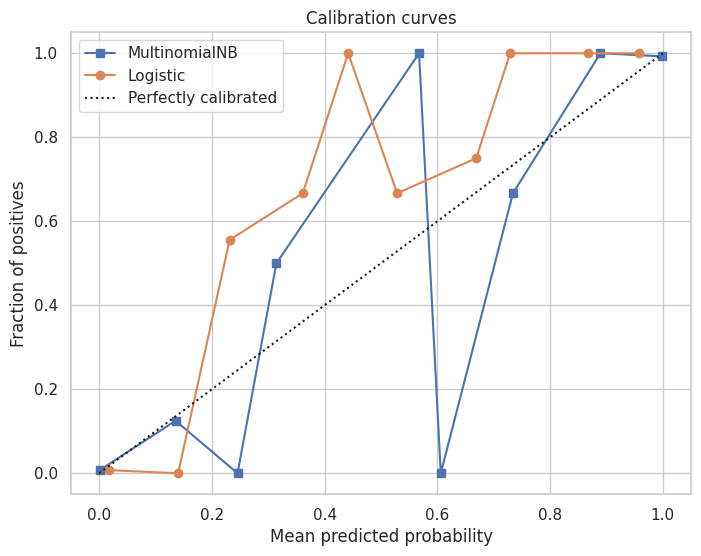

In [7]:
# Dopasowanie najlepszych estymatorów na zbiorze treningowym (GridSearchCV.refit=True)
mnb_best = gs_mnb.best_estimator_
bnb_best = gs_bnb.best_estimator_
gnb_best = gs_gnb.best_estimator_
log_best = gs_log.best_estimator_

mnb_best.fit(X_train, y_train)
bnb_best.fit(X_train, y_train)
gnb_best.fit(X_train, y_train)
log_best.fit(X_train, y_train)

# Prawdopodobieństwa na zbiorze testowym
probs_mnb = mnb_best.predict_proba(X_test)[:,1]
probs_log = log_best.predict_proba(X_test)[:,1]

# Krzywe kalibracyjne
frac_pos_mnb, mean_pred_mnb = calibration_curve(y_test, probs_mnb, n_bins=10)
frac_pos_log, mean_pred_log = calibration_curve(y_test, probs_log, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(mean_pred_mnb, frac_pos_mnb, 's-', label='MultinomialNB')
plt.plot(mean_pred_log, frac_pos_log, 'o-', label='Logistic')
plt.plot([0,1],[0,1],'k:', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.legend()
plt.title('Calibration curves')
plt.show()


- Naiwne Bayesy często są źle skalibrowane (przesadne pewności).
- Regresja logistyczna daje zwykle lepsze, bardziej wiarygodne prawdopodobieństwa; rozważyć dodatkową kalibrację (Platt/Isotonic) jeśli potrzeba prawdopodobieństw.

Wybieramy dwa n‑gramy o największej sile separacji (chi2) i rysujemy obszary decyzyjne.

Top 2 discriminative terms by chi2: ['call' 'free']


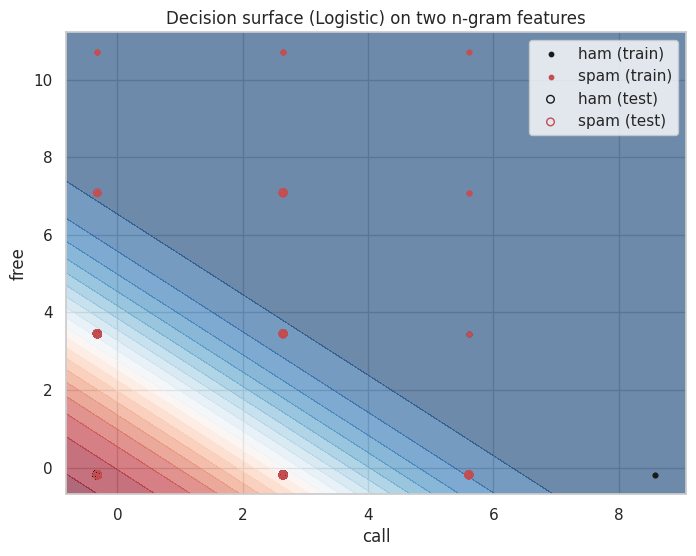

In [8]:
# Wektoryzacja do wyboru n‑gramów (CountVectorizer) — przygotowanie do chi2
best_vect = CountVectorizer(ngram_range=(1,2), min_df=2)
X_full_counts = best_vect.fit_transform(sms['text'])
feature_names = np.array(best_vect.get_feature_names_out())
# chi2: ocena cech względem etykiet
chi2_scores, pvals = chi2(X_full_counts, sms['label'])
top2_idx = np.argsort(chi2_scores)[-2:][::-1]
top2_terms = feature_names[top2_idx]
print('Top 2 discriminative terms by chi2:', top2_terms)
X_two = X_full_counts[:, top2_idx].toarray()
# Trenowanie regresji logistycznej na dwóch cechach (do wizualizacji)
from sklearn.preprocessing import StandardScaler
X2_train, X2_test, y2_train, y2_test = train_test_split(X_two, sms['label'].values, stratify=sms['label'].values, test_size=0.2, random_state=42)
sc = StandardScaler()
X2_train = sc.fit_transform(X2_train)
X2_test = sc.transform(X2_test)
clf2 = LogisticRegression(solver='liblinear')
clf2.fit(X2_train, y2_train)
# Rysowanie obszarów decyzyjnych
x_min, x_max = X2_train[:,0].min() - .5, X2_train[:,0].max() + .5
y_min, y_max = X2_train[:,1].min() - .5, X2_train[:,1].max() + .5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf2.predict_proba(grid)[:,1].reshape(xx.shape)
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.6)
plt.scatter(X2_train[y2_train==0,0], X2_train[y2_train==0,1], c='k', s=10, label='ham (train)')
plt.scatter(X2_train[y2_train==1,0], X2_train[y2_train==1,1], c='r', s=10, label='spam (train)')
plt.scatter(X2_test[y2_test==0,0], X2_test[y2_test==0,1], facecolors='none', edgecolors='k', s=30, label='ham (test)')
plt.scatter(X2_test[y2_test==1,0], X2_test[y2_test==1,1], facecolors='none', edgecolors='r', s=30, label='spam (test)')
plt.xlabel(top2_terms[0])
plt.ylabel(top2_terms[1])
plt.title('Decision surface (Logistic) on two n-gram features')
plt.legend()
plt.show()

- Dwie najwyższe cechy (chi2) częściowo separują klasy; regresja pokazuje liniową granicę.
- Wizualizacja pomaga zrozumieć wpływ pojedynczych n‑gramów na decyzję.

Prosty demonstrator KDE jako alternatywa do estymacji gęstości; w praktyce kosztowny w wysokich wymiarach.

In [11]:
mnb = gs_mnb.best_estimator_
bnb = gs_bnb.best_estimator_
mnb.fit(X_train, y_train)
bnb.fit(X_train, y_train)
pred_mnb = mnb.predict(X_test)
pred_bnb = bnb.predict(X_test)
idx_mnb_better = np.where((pred_mnb == y_test) & (pred_bnb != y_test))[0]
idx_bnb_better = np.where((pred_bnb == y_test) & (pred_mnb != y_test))[0]
print('MNB better on', len(idx_mnb_better), 'test examples; BNB better on', len(idx_bnb_better))
def show_examples(idxs, n=5):
    for i in idxs[:n]:
        print('---')
        print('y:', y_test[i], 'mnb:', pred_mnb[i], 'bnb:', pred_bnb[i])
        print(X_test[i])
print('Examples where MNB is correct and BNB is wrong:')
show_examples(idx_mnb_better, n=5)
print('Examples where BNB is correct and MNB is wrong:')
show_examples(idx_bnb_better, n=5)


MNB better on 8 test examples; BNB better on 3
Examples where MNB is correct and BNB is wrong:
---
y: 1 mnb: 1 bnb: 0
ringtoneking 84484
---
y: 1 mnb: 1 bnb: 0
Hi babe its Jordan, how r u? Im home from abroad and lonely, text me back if u wanna chat xxSP visionsms.com Text stop to stopCost 150p 08712400603
---
y: 1 mnb: 1 bnb: 0
You have 1 new voicemail. Please call 08719181513.
---
y: 1 mnb: 1 bnb: 0
You have 1 new message. Please call 08715205273
---
y: 1 mnb: 1 bnb: 0
FreeMsg>FAV XMAS TONES!Reply REAL
Examples where BNB is correct and MNB is wrong:
---
y: 0 mnb: 1 bnb: 0
Alright i have a new goal now
---
y: 0 mnb: 1 bnb: 0
Can u get pic msgs to your phone?
---
y: 1 mnb: 0 bnb: 1
Thanks for the Vote. Now sing along with the stars with Karaoke on your mobile. For a FREE link just reply with SING now.


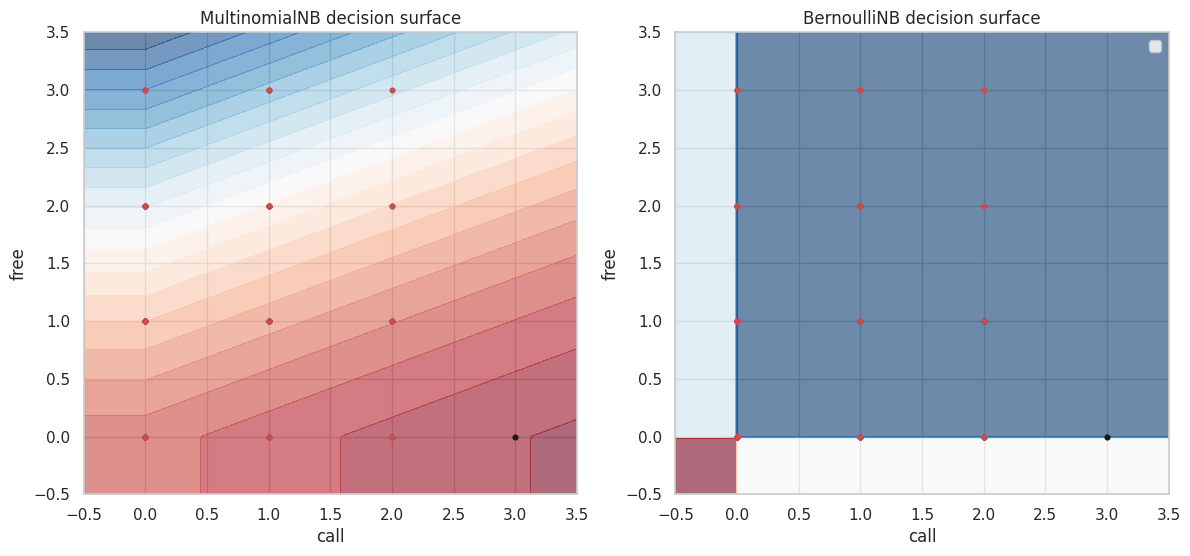

In [12]:
# Obszary decyzyjne dla MultinomialNB i BernoulliNB (dwie cechy)
X_two = X_full_counts[:, top2_idx].toarray()
X2_train_raw, X2_test_raw, y2_train, y2_test = train_test_split(X_two, sms['label'].values, stratify=sms['label'].values, test_size=0.2, random_state=42)
mnb2 = MultinomialNB()
mnb2.fit(X2_train_raw, y2_train)
bnb2 = BernoulliNB()
bnb2.fit((X2_train_raw>0).astype(int), y2_train)
x_min, x_max = X2_train_raw[:,0].min() - .5, X2_train_raw[:,0].max() + .5
y_min, y_max = X2_train_raw[:,1].min() - .5, X2_train_raw[:,1].max() + .5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_nonneg = np.clip(grid, 0, None)
probs_mnb = mnb2.predict_proba(grid_nonneg)[:,1].reshape(xx.shape)
probs_bnb = bnb2.predict_proba((grid_nonneg>0).astype(int))[:,1].reshape(xx.shape)
fig, axes = plt.subplots(1,2,figsize=(14,6))
cs = axes[0].contourf(xx, yy, probs_mnb, levels=20, cmap='RdBu', alpha=0.6)
axes[0].scatter(X2_train_raw[y2_train==0,0], X2_train_raw[y2_train==0,1], c='k', s=10, label='ham (train)')
axes[0].scatter(X2_train_raw[y2_train==1,0], X2_train_raw[y2_train==1,1], c='r', s=10, label='spam (train)')
axes[0].set_title('MultinomialNB decision surface')
axes[0].set_xlabel(top2_terms[0])
axes[0].set_ylabel(top2_terms[1])
cs2 = axes[1].contourf(xx, yy, probs_bnb, levels=20, cmap='RdBu', alpha=0.6)
axes[1].scatter(X2_train_raw[y2_train==0,0], X2_train_raw[y2_train==0,1], c='k', s=10)
axes[1].scatter(X2_train_raw[y2_train==1,0], X2_train_raw[y2_train==1,1], c='r', s=10)
axes[1].set_title('BernoulliNB decision surface')
axes[1].set_xlabel(top2_terms[0])
axes[1].set_ylabel(top2_terms[1])
plt.legend()
plt.show()

- MultinomialNB operuje na zliczeniach (gładkie prawdopodobieństwa), BernoulliNB na obecności tokenów (ostre reakcje).
- Porównanie obszarów decyzyjnych uwidacznia różnice przy rzadkich i częstych tokenach.

In [13]:
# Porównanie pasma KDE (bandwidth) z GaussianNB na wybranych dwóch cechach
from sklearn.metrics import roc_auc_score
# Prepare scaled features for density methods
X_two = X_full_counts[:, top2_idx].toarray()
X2_train_raw, X2_test_raw, y2_train, y2_test = train_test_split(X_two, sms['label'].values, stratify=sms['label'].values, test_size=0.2, random_state=42)
sc = StandardScaler()
X2_train_scaled = sc.fit_transform(X2_train_raw)
X2_test_scaled = sc.transform(X2_test_raw)
# GaussianNB baseline
gnb2 = GaussianNB()
gnb2.fit(X2_train_scaled, y2_train)
probs_gnb = gnb2.predict_proba(X2_test_scaled)[:,1]
print('GaussianNB ROC AUC on two features:', roc_auc_score(y2_test, probs_gnb))
# KDE sweep
for bw in [0.1, 0.3, 0.6, 1.0, 2.0]:
    kdes = {}
    priors = {}
    for c in np.unique(y2_train):
        Xc = X2_train_scaled[y2_train==c]
        kdes[c] = KernelDensity(bandwidth=bw).fit(Xc)
        priors[c] = Xc.shape[0] / X2_train_scaled.shape[0]
    log_probs = np.vstack([kdes[c].score_samples(X2_test_scaled) + np.log(priors[c]) for c in sorted(kdes.keys())]).T
    a = log_probs - log_probs.max(axis=1)[:,None]
    probs = np.exp(a)
    probs = probs / probs.sum(axis=1)[:,None]
    auc = roc_auc_score(y2_test, probs[:,1])
    print(f'KDE bw={bw} ROC AUC: {auc:.4f}')


GaussianNB ROC AUC on two features: 0.7972994566954298
KDE bw=0.1 ROC AUC: 0.7973
KDE bw=0.3 ROC AUC: 0.7973
KDE bw=0.6 ROC AUC: 0.7973
KDE bw=1.0 ROC AUC: 0.7973
KDE bw=2.0 ROC AUC: 0.7959


- Małe bandwidth -> dopasowanie do szumu (overfit).
- Duże bandwidth -> zbyt gładkie gęstości (underfit).
- Dla 2‑wymiarowych projekcji KDE może być konkurencyjne względem GaussianNB przy odpowiednim h.

In [14]:
from sklearn.base import BaseEstimator
class KDEBayesClassifier(BaseEstimator):
    def __init__(self, bandwidth=1.0):
        self.bandwidth = bandwidth
    def fit(self, X, y):
        X = np.asarray(X)
        self.classes_ = np.unique(y)
        self.kdes_ = {}
        self.class_prior_ = {}
        for c in self.classes_:
            Xc = X[y==c]
            self.kdes_[c] = KernelDensity(bandwidth=self.bandwidth)
            self.kdes_[c].fit(Xc)
            self.class_prior_[c] = Xc.shape[0] / X.shape[0]
        return self
    def predict_proba(self, X):
        X = np.asarray(X)
        log_probs = np.zeros((X.shape[0], len(self.classes_)))
        for i, c in enumerate(self.classes_):
            log_dens = self.kdes_[c].score_samples(X)
            log_probs[:, i] = log_dens + np.log(self.class_prior_[c])
        a = log_probs - log_probs.max(axis=1)[:,None]
        probs = np.exp(a)
        probs = probs / probs.sum(axis=1)[:,None]
        return probs
    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]

kde_clf = KDEBayesClassifier(bandwidth=1.0)
kde_clf.fit(X2_train, y2_train)
print('KDE Bayes test accuracy on two features:', (kde_clf.predict(X2_test) == y2_test).mean())


KDE Bayes test accuracy on two features: 0.8932735426008969


- KDE w dużej liczbie wymiarów jest kosztowne; praktycznie używać dla niskowymiarowych projekcji lub per‑feature KDE.
- Służy jako ilustracja elastycznego podejścia do estymacji gęstości.